# Amazon Sales Dataset

This project analyzes customer ratings and review data for over 1,000 Amazon products. The goal is to understand whether higher discounts are associated with better customer satisfaction or higher ratings, and to identify which product categories perform best.

**Research Questions**
1. Does a higher discount percentage lead to higher product ratings?
2. Which product categories have the highest average ratings?
3. Are heavily discounted products more likely to receive customer reviews?
4. What is the relationship between actual price and customer ratings?
5. Which product categories receive the most customer reviews, based on rating count?

-----

## Setup and data cleaning:

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# link from the print in smartphones Specification & Prices.py
path = '/Users/xujing/.cache/kagglehub/datasets/karkavelrajaj/amazon-sales-dataset/versions/1'

# ls
print(os.listdir(path))

# find .cvs
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]
print("CSV files:", csv_files)

# ls fisrt csv files 
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)



['amazon.csv']
CSV files: ['amazon.csv']


In [3]:
column_types = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

column_types

,Column Name,Data Type
0,product_id,str
1,product_name,str
2,category,str
3,discounted_price,str
4,actual_price,str
5,discount_percentage,str
6,rating,str
7,rating_count,str
8,about_product,str
9,user_id,str


In [4]:
pd.set_option("display.max_columns", None)
df.head(3)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


### Convert price, rating, and rating_count columns from string/object type to numeric type

In [5]:
df["discounted_price"] = (
    df["discounted_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["discounted_price"] = pd.to_numeric(df["discounted_price"], errors="coerce")

df["actual_price"] = (
    df["actual_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["actual_price"] = pd.to_numeric(df["actual_price"], errors="coerce")

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

df["rating_count"] = (
    df["rating_count"]
    .str.replace(",", "", regex=False)
)

df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

df["discount_percentage"] = (
    df["discount_percentage"]
    .str.replace("%", "", regex=False)
)

df["discount_percentage"] = pd.to_numeric(df["discount_percentage"], errors="coerce")

df["main_category"] = df["category"].str.split("|").str[0]

df["main_category"].value_counts()

main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

----

## Basic Analysis: Research Questions

### 1. Does a higher discount percentage lead to higher product ratings?

In [6]:
rq1_corr = df[["discount_percentage", "rating"]].corr()

rq1_corr

,discount_percentage,rating
discount_percentage,1.000000,-0.155375
rating,-0.155375,1.000000


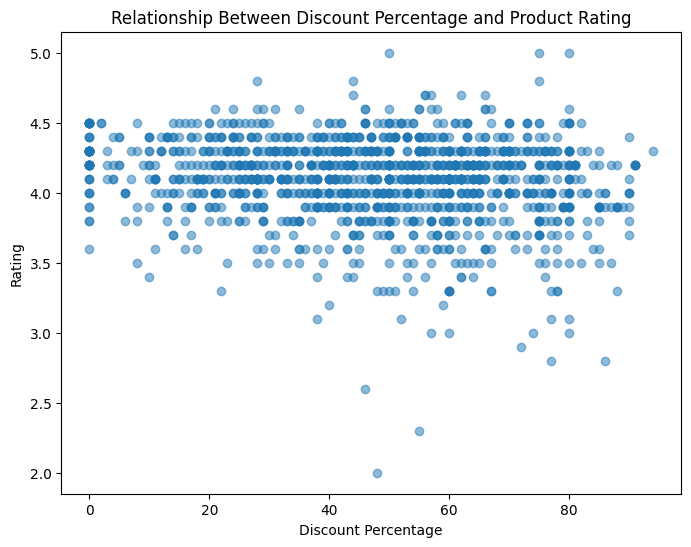

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(df["discount_percentage"], df["rating"], alpha=0.5)
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")
plt.title("Relationship Between Discount Percentage and Product Rating")
plt.show()

The scatter plot shows that product ratings are mostly concentrated between 3.8 and 4.5 across different discount levels. There is no clear upward trend, suggesting that higher discounts do not necessarily lead to higher ratings.

----

### 2. Which product categories have the highest average ratings?

In [8]:
rq2_table = (
    df.groupby("main_category")["rating"]
    .mean()
    .reset_index()
    .rename(columns={"rating": "average_rating"})
    .sort_values(by="average_rating", ascending=False)
)

rq2_table.head(10)

,main_category,average_rating
7,OfficeProducts,4.309677
8,Toys&Games,4.300000
5,HomeImprovement,4.250000
1,Computers&Accessories,4.154967
2,Electronics,4.081749
4,Home&Kitchen,4.040716
3,Health&PersonalCare,4.000000
6,MusicalInstruments,3.900000
0,Car&Motorbike,3.800000


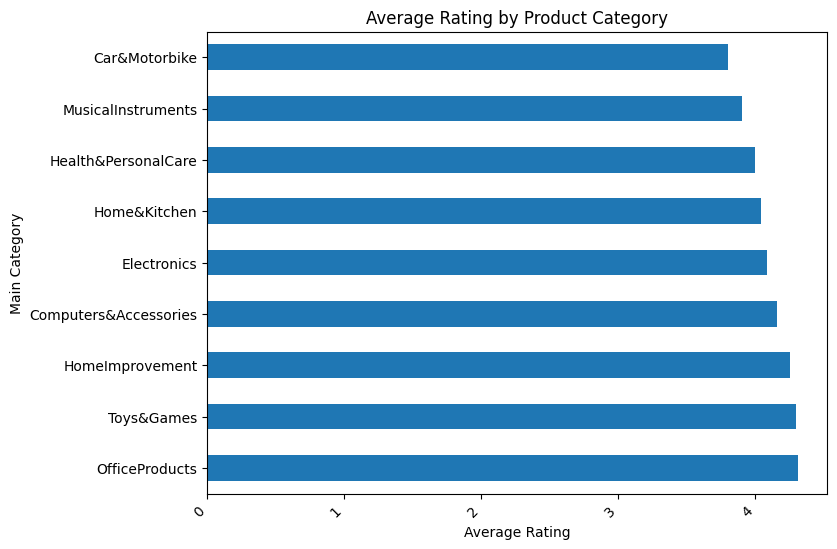

In [9]:
rq2_plot = (
    df.groupby("main_category")["rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))
rq2_plot.plot(kind="barh")
plt.xlabel("Average Rating")
plt.ylabel("Main Category")
plt.title("Average Rating by Product Category")
plt.xticks(rotation=45, ha="right")
plt.show()

OfficeProducts, Toys&Games, and HomeImprovement have the highest average ratings, while Car&Motorbike has the lowest average rating.

----

### 3. Are heavily discounted products more likely to receive customer reviews?

In [10]:
df["discount_group"] = pd.cut(
    df["discount_percentage"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20%", "21-40%", "41-60%", "61-80%", "81-100%"]
)

rq3_table = (
    df.groupby("discount_group")["rating_count"]
    .mean()
    .reset_index()
    .rename(columns={"rating_count": "average_rating_count"})
)

rq3_table

,discount_group,average_rating_count
0,0-20%,16406.015267
1,21-40%,20265.585799
2,41-60%,15644.307087
3,61-80%,23295.433862
4,81-100%,9587.762712


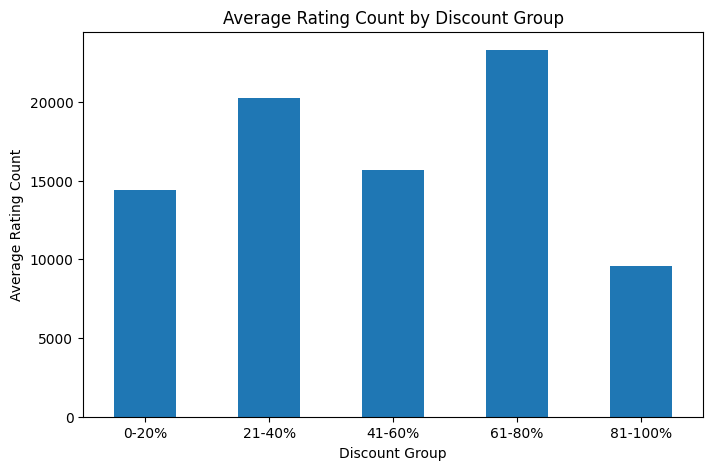

In [11]:
df["discount_group"] = pd.cut(
    df["discount_percentage"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20%", "21-40%", "41-60%", "61-80%", "81-100%"],
    include_lowest=True
)

rq3_plot = (
    df.groupby("discount_group", observed=False)["rating_count"]
    .mean()
)

plt.figure(figsize=(8, 5))
rq3_plot.plot(kind="bar")
plt.xlabel("Discount Group")
plt.ylabel("Average Rating Count")
plt.title("Average Rating Count by Discount Group")
plt.xticks(rotation=0)
plt.show()

OfficeProducts, Toys&Games, and HomeImprovement have the highest average ratings, while Car&Motorbike has the lowest average rating.

----

### 4. What is the relationship between actual price and customer ratings?

In [12]:
rq4_corr = df[["actual_price", "rating"]].corr()

rq4_corr

,actual_price,rating
actual_price,1.000000,0.121642
rating,0.121642,1.000000


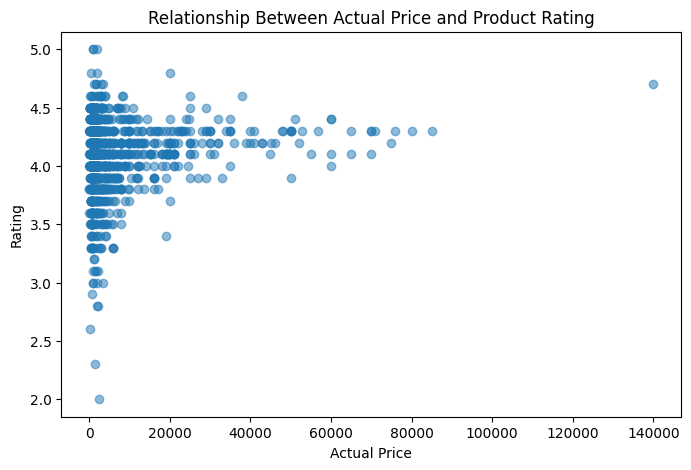

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df["actual_price"], df["rating"], alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Rating")
plt.title("Relationship Between Actual Price and Product Rating")
plt.show()

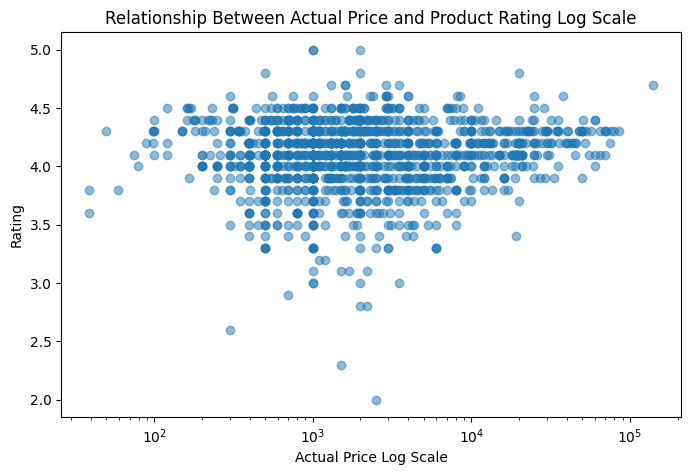

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df["actual_price"], df["rating"], alpha=0.5)
plt.xscale("log")
plt.xlabel("Actual Price Log Scale")
plt.ylabel("Rating")
plt.title("Relationship Between Actual Price and Product Rating Log Scale")
plt.show()

Actual price has a weak positive relationship with product rating. Higher-priced products may have slightly higher ratings, but the relationship is not strong.

### 5. Which product categories receive the most customer reviews, based on rating count?

In [15]:
rq5_table = (
    df.groupby("main_category")["rating_count"]
    .sum()
    .reset_index()
    .rename(columns={"rating_count": "total_rating_count"})
    .sort_values(by="total_rating_count", ascending=False)
)

rq5_table.head(10)

,main_category,total_rating_count
2,Electronics,15778848.0
1,Computers&Accessories,7728689.0
4,Home&Kitchen,2991069.0
7,OfficeProducts,149675.0
6,MusicalInstruments,88882.0
8,Toys&Games,15867.0
5,HomeImprovement,8566.0
3,Health&PersonalCare,3663.0
0,Car&Motorbike,1118.0


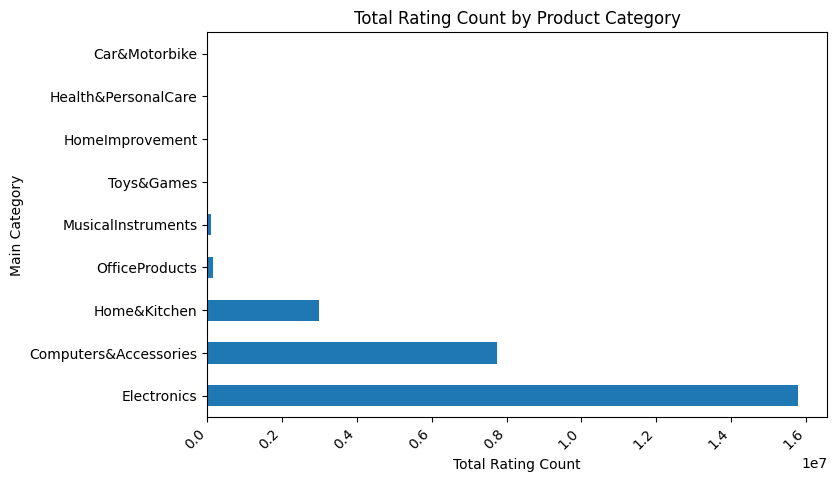

In [16]:
rq5_plot = (
    df.groupby("main_category")["rating_count"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
rq5_plot.plot(kind="barh")
plt.xlabel("Total Rating Count")
plt.ylabel("Main Category")
plt.title("Total Rating Count by Product Category")
plt.xticks(rotation=45, ha="right")
plt.show()

Electronics receives the highest total number of customer reviews by far.

----

### Other Distributions 

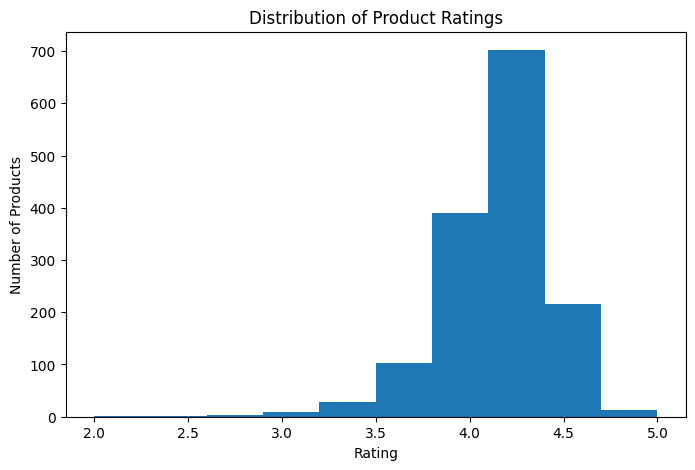

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df["rating"].dropna(), bins=10)
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Ratings")
plt.show()

Most products have discount percentages between 40% and 70%, with the highest concentration around 50% to 60%. This suggests that discounting is a common pricing strategy in this dataset.

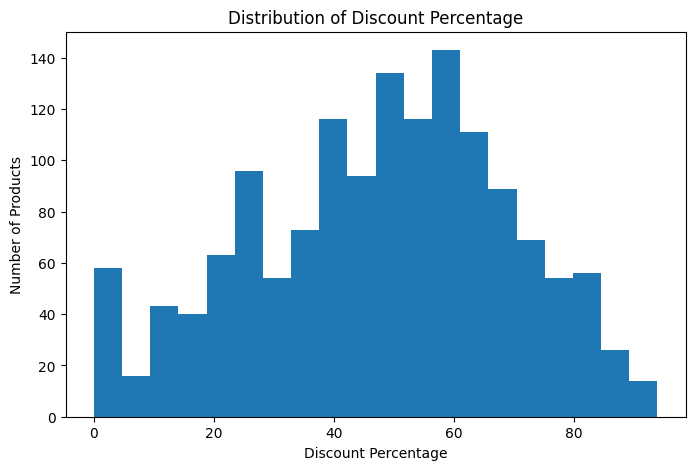

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(df["discount_percentage"].dropna(), bins=20)
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")
plt.title("Distribution of Discount Percentage")
plt.show()

Product ratings are highly concentrated between 4.0 and 4.5, with very few products rated below 3.5. This indicates that most products in the dataset have generally positive customer feedback.

----

### Summary of Visualizations

1. The visualizations show that discounts are widely used in this Amazon product dataset, but higher discounts do not clearly lead to better customer ratings. Most products have discounts between 40% and 70%, especially around 50% to 60%, which suggests that discounting is a common pricing strategy.

2. Product ratings are generally high. Most products are rated between 4.0 and 4.5, meaning that customer feedback is mostly positive. There are very few products with very low ratings.

3. The scatter plot between discount percentage and rating shows no clear upward trend. This means that offering a higher discount does not necessarily improve product ratings. This result is also supported by the weak negative correlation between discount percentage and rating.

4. For product categories, OfficeProducts, Toys&Games, and HomeImprovement have the highest average ratings. This suggests that customers are more satisfied with products in these categories. However, some categories may have fewer products, so the average rating should be interpreted carefully.

5. The discount group chart shows that products with 61%–80% discounts receive the highest average number of reviews. However, the 81%–100% discount group receives fewer reviews, so very large discounts do not always lead to more customer reviews.

6. The scatter plot between actual price and rating shows only a weak positive relationship. Higher-priced products may have slightly higher ratings, but the relationship is not strong. Most ratings still stay around 4.0 to 4.5 across different price levels.

7. Finally, the total review count by category shows that Electronics receives the most customer reviews by far, followed by Computers&Accessories and Home&Kitchen. This suggests that electronics-related products have the highest customer engagement in this dataset.

----


## Advanced Analysis: Feature Engineering and Product Performance

### 1. Weighted Average Rating by Category

### 2. Discount Effectiveness

### 3. Value Score

### 4. Product Performance Score

### 5. Rating Prediction Model

### 6. Feature Importance